**Running the TP:** Keep this notebook with the `datasets` folder for a local run. On Kaggle, upload the four data files as a dataset, attach that dataset to the notebook, then choose **Run All**. The loading cells find the files by name and check their columns. The data files are [Horse Colic](https://www.kaggle.com/datasets/uciml/horse-colic), [Pima diabetes](https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset), [Titanic training data](https://www.kaggle.com/datasets/hesh97/titanicdataset-traincsv), and the `data.xlsx` supplied with the original TP.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

def find_data_file(filename, required_columns=()):
    """Find a packaged file locally or in an attached Kaggle dataset."""
    roots = [Path.cwd(), Path('/kaggle/input')]
    candidates = [p for root in roots if root.exists() for p in root.rglob(filename)]
    for path in candidates:
        if not required_columns or set(required_columns).issubset(pd.read_csv(path, nrows=0).columns):
            return path
    raise FileNotFoundError(
        f'{filename} was not found with the expected columns. '
        'Place the datasets folder beside this notebook, or attach the files as a Kaggle dataset.'
    )

print(f'NumPy {np.__version__}; pandas {pd.__version__}')

NumPy 2.0.2; pandas 2.3.3


**Interpretation:** The version numbers identify the libraries used for this run.

In [2]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

print('Imports ready. All examples below run in the standard Kaggle Python environment.')

Imports ready. All examples below run in the standard Kaggle Python environment.


**Interpretation:** The preprocessing and feature-selection classes are ready for later examples.


## Method (1): Create a Dataframe from multiple series

We start by creating a Pandas series which is like a column in a table with index.

In [3]:
# Create two Series with partly different student indexes.
age = pd.Series([23, 22, 25], index=['Student1', 'Student2', 'Student3'], name='age')
height = pd.Series([155, 175, 168], index=['Student1', 'Student3', 'Student4'], name='height')
display(age.to_frame(), height.to_frame())

,age
Student1,23
Student2,22
Student3,25


,height
Student1,155
Student3,175
Student4,168


**Interpretation:** The two Series have different student labels, which makes their alignment visible in the next output.

**A dataframe** can be composed of multiple series, or it can be defined as a collection of series that can be used to analyze data.

In [4]:
stat = pd.DataFrame({'age': age, 'height': height})
display(stat)

,age,height
Student1,23.0,155.0
Student2,22.0,NaN
Student3,25.0,175.0
Student4,NaN,168.0


**Interpretation:** Pandas aligns the Series by student label; students absent from a Series receive `NaN` in that column.

## Method (2): Load a Dataframe



In [5]:
# Load the complete horse.csv file supplied in datasets/horse_colic.
horse_file = find_data_file('horse.csv', ['rectal_temp', 'pulse', 'outcome'])
stat2 = pd.read_csv(horse_file)
print('Horse-colic shape:', stat2.shape)
display(stat2.head())

Horse-colic shape: (299, 28)


,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


**Interpretation:** This Kaggle file has 299 rows; missing entries are `NaN`.

In [6]:
# Load the Excel file supplied with the original TP.
excel_file = find_data_file('data.xlsx')
stat3 = pd.read_excel(excel_file, index_col=0, na_values=['NaN', '?'])
stat3.index.name = 'student'
print('Excel data shape:', stat3.shape)
display(stat3)

Excel data shape: (4, 2)


,age,height
student,,
Etudiant1,23.0,155.0
Etudiant2,22.0,NaN
Etudiant3,25.0,175.0
Etudiant4,NaN,168.0


**Interpretation:** The supplied workbook contains four students, with age and height in separate columns. The text `NaN` is treated as missing data.

## Method(3): Create a Dataframe



In [7]:
# Construct a small DataFrame with missing values for the cleaning examples.
df = pd.DataFrame({
    'Type': ['Student1', 'Student2', 'Student3', 'Student4'],
    'order': [2, 10, np.nan, 10],
    'age': [23, np.nan, 25, 0],
    'height': [155, 160, np.nan, 160],
})
display(df)

,Type,order,age,height
0,Student1,2.0,23.0,155.0
1,Student2,10.0,NaN,160.0
2,Student3,NaN,25.0,NaN
3,Student4,10.0,0.0,160.0


**Interpretation:** Three numeric cells are intentionally missing so the following cleaning methods have observable effects.

<p style="font-family: Arial; font-size:1.75em;color:red; font-style:bold"><br>
III.Get information about a dataset</p><br>

In [8]:
# Load the full training CSV from the packaged Kaggle dataset.
titanic_file = find_data_file('train.csv', ['PassengerId', 'Survived', 'Pclass'])
data = pd.read_csv(titanic_file)
print('Titanic data loaded:', data.shape)

Titanic data loaded: (891, 12)


**Interpretation:** The packaged Titanic training file contains 891 passenger rows and 12 columns. The `Survived` column is available for the later inspection steps.

In [9]:
display(data.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Interpretation:** The first rows show the target `Survived` alongside passenger details and visible missing entries.

In [10]:
print('Rows, columns:', data.shape)

Rows, columns: (891, 12)


**Interpretation:** Shape reports the number of passenger records and columns; it does not measure missingness.

In [11]:
display(data.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Interpretation:** The head confirms the column names and a sample of the first records.

In [12]:
display(data.tail())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


**Interpretation:** The tail checks the last records and helps catch truncated or misread files.

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Interpretation:** Non-null counts reveal incomplete columns, while dtypes distinguish numeric and text fields.

In [14]:
display(data.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Interpretation:** These summaries cover numeric columns only; `count` is lower where a numeric column has missing values.

<p style="font-family: Arial; font-size:1.75em;color:red; font-style:bold"><br>
IV Data Preparation </p><br>


<font color='blue' ><h3>
IV.1. Data Cleaning </p><h3>

## (1): Checking for NAN values

In [15]:
print('Any missing values?', df.isnull().values.any())

Any missing values? True


**Interpretation:** `True` confirms that at least one cell in the example table is missing.

In [16]:
display(df.isnull().sum().rename('missing_count').to_frame())

,missing_count
Type,0
order,1
age,1
height,1


**Interpretation:** The per-column counts locate the missing values; the text `Type` column is complete.

In [17]:
print('Total missing cells:', df.isnull().sum().sum())

Total missing cells: 3


**Interpretation:** This is the sum of the per-column missing counts.

In [18]:
print('Any observed values?', df.notnull().values.any())

Any observed values? True


**Interpretation:** `True` means the table contains at least one observed value.

In [19]:
print('Total observed cells:', df.notnull().sum().sum())

Total observed cells: 13


**Interpretation:** Observed cells plus missing cells equal the table's total number of cells.

In [20]:
display(df.isna().sum().rename('missing_count').to_frame())

,missing_count
Type,0
order,1
age,1
height,1


**Interpretation:** `isna()` is an alias of `isnull()`, so these counts match the earlier output.

In [21]:
print('Total missing cells using isna:', df.isna().sum().sum())

Total missing cells using isna: 3


**Interpretation:** The total matches the earlier `isnull()` calculation.

In [22]:
print('Total observed cells using notna:', df.notna().sum().sum())

Total observed cells using notna: 13


**Interpretation:** The total matches the earlier `notnull()` calculation.

## (2): Common Methods to Imputing Missing Data

There are different methods that we use to impute missing data such that: Mean strategy, Median technique and Mode technique.\

#### *) Mean strategy


In [23]:
# Mean imputation affects only numeric columns; keep the source df unchanged.
df_mean = df.copy()
numeric = df_mean.select_dtypes(include='number').columns
df_mean[numeric] = df_mean[numeric].fillna(df_mean[numeric].mean())
display(df_mean)

,Type,order,age,height
0,Student1,2.000000,23.0,155.000000
1,Student2,10.000000,16.0,160.000000
2,Student3,7.333333,25.0,158.333333
3,Student4,10.000000,0.0,160.000000


**Interpretation:** Each missing numeric value is replaced by its column mean; the original `df` stays available for comparison.

#### *) Median technique


In [24]:
# Median is less affected by extreme observations than mean.
df_median = df.copy()
numeric = df_median.select_dtypes(include='number').columns
df_median[numeric] = df_median[numeric].fillna(df_median[numeric].median())
display(df_median)

,Type,order,age,height
0,Student1,2.0,23.0,155.0
1,Student2,10.0,23.0,160.0
2,Student3,10.0,25.0,160.0
3,Student4,10.0,0.0,160.0


**Interpretation:** Median imputation uses the middle observed value in each numeric column and can resist outliers better than a mean.

#### *) Mode technique (most frequent value)


In [25]:
# Mode imputation uses the most common observed height.
df_mode = df.copy()
df_mode['height'] = df_mode['height'].fillna(df_mode['height'].mode().iloc[0])
display(df_mode)

,Type,order,age,height
0,Student1,2.0,23.0,155.0
1,Student2,10.0,NaN,160.0
2,Student3,NaN,25.0,160.0
3,Student4,10.0,0.0,160.0


**Interpretation:** The missing height becomes 160, the most frequent observed height.

In [26]:
# Apply the same approach to order; ties use pandas' first sorted mode.
df_mode['order'] = df_mode['order'].fillna(df_mode['order'].mode().iloc[0])
display(df_mode)

,Type,order,age,height
0,Student1,2.0,23.0,155.0
1,Student2,10.0,NaN,160.0
2,Student3,10.0,25.0,160.0
3,Student4,10.0,0.0,160.0


**Interpretation:** The missing order becomes 10, its most frequent observed value.

<font color='blue' ><h3>
IV.2. Feature selection </p><h3>

Feature selection is used to determine the best set of features for building useful models.

In [27]:
# Load the packaged Pima diabetes CSV and keep the TP's short column names.
pima_file = find_data_file('diabetes.csv', ['Pregnancies', 'Glucose', 'Outcome'])
dataframe = pd.read_csv(pima_file)
dataframe.columns = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
names = dataframe.columns.tolist()
print('Pima shape:', dataframe.shape)
display(dataframe.head())

Pima shape: (768, 9)


,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


**Interpretation:** This 768-row file has filled measurements, so its feature ranking differs from the older raw data.

After loading the dataframe, we convert it to a NumPy array to speed up the
calculation with separation the features and labels.

In [28]:
array = dataframe.to_numpy()
X1 = array[:, 0:8]
Y1 = array[:, 8].astype(int)
print('Feature matrix:', X1.shape, 'Target:', Y1.shape)

Feature matrix: (768, 8) Target: (768,)


**Interpretation:** The feature matrix excludes the class column, which becomes the target vector.

In [29]:
print('SelectKBest and chi2 are available.')

SelectKBest and chi2 are available.


**Interpretation:** The next cell fits the chi-squared filter to the nonnegative feature matrix.

In [30]:
# Chi-squared requires nonnegative features; these columns satisfy that condition.
test = SelectKBest(score_func=chi2, k=4)
fit = test.fit(X1, Y1)
display(pd.Series(fit.scores_, index=names[:-1], name='chi2_score').sort_values(ascending=False).to_frame())

,chi2_score
test,6107.908339
plas,1439.168619
skin,181.546053
age,181.303689
preg,111.519691
mass,111.489994
pres,47.267258
pedi,5.392682


**Interpretation:** Higher chi-squared scores indicate stronger univariate associations with the class; scores depend on each feature's scale.

In [31]:
feature_scores = pd.Series(fit.scores_, index=names[:-1], name='chi2_score')
selected_features = feature_scores.index[fit.get_support()].tolist()
print('Four selected features:', selected_features)
display(feature_scores.sort_values(ascending=False).to_frame())

Four selected features: ['plas', 'skin', 'test', 'age']


,chi2_score
test,6107.908339
plas,1439.168619
skin,181.546053
age,181.303689
preg,111.519691
mass,111.489994
pres,47.267258
pedi,5.392682


**Interpretation:** The four selected columns are the ones with the highest scores in this sample.

In [32]:
features = fit.transform(X1)
print('Selected matrix shape:', features.shape)
display(pd.DataFrame(features[:5], columns=selected_features))

Selected matrix shape: (768, 4)


,plas,skin,test,age
0,148.0,35.0,169.5,50.0
1,85.0,29.0,102.5,31.0
2,183.0,32.0,169.5,32.0
3,89.0,23.0,94.0,21.0
4,137.0,35.0,168.0,33.0


**Interpretation:** The transformed table retains only the selected columns and keeps the original row order.

### Interpretation:

For this packaged Pima file, the four selected features are `plas`, `skin`, `test`, and `age`. The chi-squared score ranks each feature on its own and depends on its numeric scale; selection should be fitted within a training pipeline when assessing a predictive model.

<font color='blue' ><h3>
IV.3. Data transformation </p><h3>

## A.Categorical features

Most scikit-learn models need numbers, so categories must be encoded before modeling. The choice depends on whether a category has a meaningful order. Education level is ordered; sex and blood type are not. The next cells show ordinal encoding followed by one-hot encoding on four records.

In [33]:
print('Categorical encoding example: four records and three features.')

Categorical encoding example: four records and three features.


**Interpretation:** The example includes an ordered education feature and two unordered categorical features.

In [34]:
X1_cat = pd.DataFrame([
    ['M', 'O-', 'medium'], ['M', 'O-', 'high'],
    ['F', 'O+', 'high'], ['F', 'AB', 'low'],
], columns=['sex', 'blood_type', 'edu_level'])
display(X1_cat)

,sex,blood_type,edu_level
0,M,O-,medium
1,M,O-,high
2,F,O+,high
3,F,AB,low


**Interpretation:** Education can be ranked low–medium–high; sex and blood type are nominal categories.

In [35]:
display(X1_cat)

,sex,blood_type,edu_level
0,M,O-,medium
1,M,O-,high
2,F,O+,high
3,F,AB,low


**Interpretation:** This is the unchanged categorical input before encoding.

### 1.Ordinal Feature

Education levels have a natural order: low, medium, high. We provide that order to `OrdinalEncoder` so its numeric codes follow the meaning of the data. The numbers express rank, not a measured distance between levels.

In [36]:
# Set the intended education order explicitly.
encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])
X1_encoded = X1_cat.copy()
X1_encoded['edu_level'] = encoder.fit_transform(X1_cat[['edu_level']]).ravel()
display(X1_encoded)

,sex,blood_type,edu_level
0,M,O-,1.0
1,M,O-,2.0
2,F,O+,2.0
3,F,AB,0.0


**Interpretation:** The ordered labels map to 0, 1, and 2, preserving their rank without claiming equal real-world distances.

In [37]:
display(X1_encoded)

,sex,blood_type,edu_level
0,M,O-,1.0
1,M,O-,2.0
2,F,O+,2.0
3,F,AB,0.0


**Interpretation:** Only `edu_level` changes; nominal columns remain text until one-hot encoding.

The order of education levels must be supplied explicitly. This example has no missing education values; if a real dataset does, decide how to handle them before fitting the encoder.

In [38]:
X = X1_cat.copy()
display(X)

,sex,blood_type,edu_level
0,M,O-,medium
1,M,O-,high
2,F,O+,high
3,F,AB,low


**Interpretation:** This fresh copy provides the same starting values for the combined encoding example.

In [39]:
encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])
print('Ordered categories:', encoder.categories[0] if hasattr(encoder, 'categories') else ['low', 'medium', 'high'])

Ordered categories: ['low', 'medium', 'high']


**Interpretation:** The explicit category order prevents alphabetical ordering from changing the intended ranks.

In [40]:
X['edu_level'] = encoder.fit_transform(X[['edu_level']]).ravel()
display(X)

,sex,blood_type,edu_level
0,M,O-,1.0
1,M,O-,2.0
2,F,O+,2.0
3,F,AB,0.0


**Interpretation:** The ordered education values are numeric and ready to join the one-hot columns.

#### OrdinalEncoder vs LabelEncoder

OrdinalEncoder is for 2D data with the shape (n_samples, n_features)

LabelEncoder is for 1D data with the shape (n_samples,))

### 2. Nominal Features

Sex and blood type have no ranking. One-hot encoding makes a separate 0/1 column for each category, avoiding an artificial order.

Create a `OneHotEncoder` and request integer output. The example uses dense output because this table has only four rows; for a large dataset, a sparse matrix can save memory.

In [41]:
# sparse_output is supported by current scikit-learn on Kaggle.
onehot = OneHotEncoder(dtype=int, handle_unknown='ignore', sparse_output=False)
print('OneHotEncoder ready for sex and blood type.')

OneHotEncoder ready for sex and blood type.


**Interpretation:** The encoder will create one binary column per observed nominal category.

Fit the encoder to `sex` and `blood_type`, take the generated column names from the encoder, and add the already encoded education column.

In [42]:
nominals = pd.DataFrame(
    onehot.fit_transform(X[['sex', 'blood_type']]),
    columns=onehot.get_feature_names_out(['sex', 'blood_type']),
    index=X.index,
)
nominals['edu_level'] = X['edu_level']
display(nominals)

,sex_F,sex_M,blood_type_AB,blood_type_O+,blood_type_O-,edu_level
0,0,1,0,0,1,1.0
1,0,1,0,0,1,2.0
2,1,0,0,1,0,2.0
3,1,0,1,0,0,0.0


**Interpretation:** Each record has one active sex column and one active blood-type column; education keeps its ordinal code.

Compare the output (nominals) to our original data to make sure everything came through the right way.

In [43]:
display(nominals)

,sex_F,sex_M,blood_type_AB,blood_type_O+,blood_type_O-,edu_level
0,0,1,0,0,1,1.0
1,0,1,0,0,1,2.0
2,1,0,0,1,0,2.0
3,1,0,1,0,0,0.0


**Interpretation:** The one-hot table contains numeric features suitable for many machine-learning estimators.

In [44]:
display(X)

,sex,blood_type,edu_level
0,M,O-,1.0
1,M,O-,2.0
2,F,O+,2.0
3,F,AB,0.0


**Interpretation:** Comparing this source table with the encoded table verifies that the categories mapped as expected.

## B. Feature scaling

Features with very different units can have an uneven influence on distance-based and optimization-based methods. Standardization centers values and divides by standard deviation. Min-max scaling maps observed values to a chosen range.

For a predictive model, split into training and test sets first. Fit the scaler on the training set, then transform both sets with that fitted scaler. The small examples below demonstrate the calculations rather than model evaluation.



Feature scaling is a very important step in the preprocessing pipeline.

For predictive modeling, split into training and test sets first. Fit a scaler on the training set only, then use that fitted scaler to transform both sets; this prevents information from the test set leaking into training. The examples below illustrate the transformations, not a model evaluation.



Standardization is a transformation that centers the data by removing the mean value of each feature and then scale it by dividing (non-constant) features by their standard deviation. After standardizing data the mean will be zero and the standard deviation one.
Standardization can drastically improve the performance of models. For instance, many learning algorithms (such as Support Vector Machines) assume that all features are centered around zero and have variance in the same order.
Depending on your needs and data, sklearn provides a bunch of scalers: StandardScaler, MinMaxScaler, MaxAbsScaler and RobustScaler.

### Methode (1) Standardization (Standard Scaler)

`StandardScaler` computes `(x - mean) / standard_deviation` using observed values. Nonconstant columns then have mean near zero and standard deviation near one. The next example scales the `f3` column and leaves missing values in place.

In [45]:
Y = pd.DataFrame(np.array([
    5, 7, 8, np.nan, np.nan, np.nan, -5, 0, 25,
    999, 1, -1, np.nan, 0, np.nan,
]).reshape(5, 3), columns=['f1', 'f2', 'f3'])
display(Y)

,f1,f2,f3
0,5.0,7.0,8.0
1,NaN,NaN,NaN
2,-5.0,0.0,25.0
3,999.0,1.0,-1.0
4,NaN,0.0,NaN


**Interpretation:** The `f3` column includes a missing value and values on different scales for the standardization example.

In [46]:
# Fit on observed f3 values and leave missing values missing.
scaler = StandardScaler()
scaled_f3 = scaler.fit_transform(Y[['f3']])
display(pd.DataFrame({'f3': Y['f3'], 'f3_standardized': scaled_f3.ravel()}))

,f3,f3_standardized
0,8.0,-0.247357
1,NaN,NaN
2,25.0,1.329544
3,-1.0,-1.082187
4,NaN,NaN


**Interpretation:** Observed `f3` values are centered and scaled; its missing entry remains missing.

### Method(2): Normalization:

`MinMaxScaler` maps each column to a specified range, usually 0 to 1. For the default range, the formula is

$$x_{scaled} = \frac{x - \min(x)}{\max(x) - \min(x)}.$$

It is sensitive to extreme values because the minimum and maximum set the scale. The car example below compares the calculation by hand with scikit-learn.

#### Method 1:  Manual Computation

In [47]:
df_cars = pd.DataFrame(
    [[120000, 11], [250000, 11.5], [175000, 15.8], [350000, 17], [400000, 10]],
    columns=['odometer_reading', 'fuel_economy'],
)
display(df_cars)

,odometer_reading,fuel_economy
0,120000,11.0
1,250000,11.5
2,175000,15.8
3,350000,17.0
4,400000,10.0


**Interpretation:** Odometer values are far larger numerically than fuel economy values, which motivates scaling.

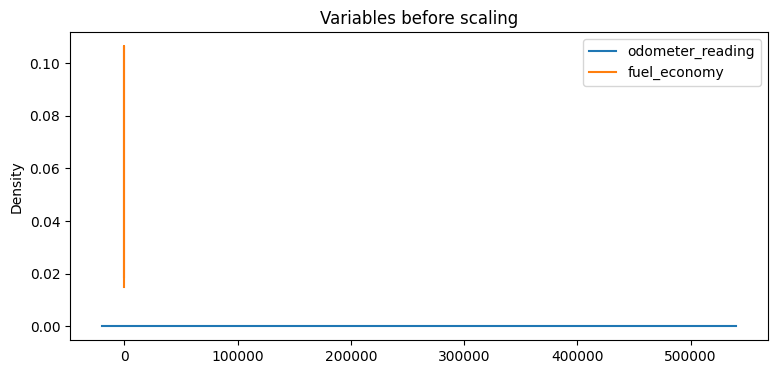

In [48]:
ax = df_cars.plot(kind='density', figsize=(9, 4))
ax.set_title('Variables before scaling')
plt.show()

**Interpretation:** On the original axes, the large odometer scale separates the two density curves.

In [49]:
def min_max_scaling(frame):
    result = frame.copy()
    for column in result.columns:
        span = result[column].max() - result[column].min()
        result[column] = (result[column] - result[column].min()) / span if span else 0.0
    return result

df_cars_normalized = min_max_scaling(df_cars)
display(df_cars_normalized)

,odometer_reading,fuel_economy
0,0.000000,0.142857
1,0.464286,0.214286
2,0.196429,0.828571
3,0.821429,1.000000
4,1.000000,0.000000


**Interpretation:** Each column now ranges from 0 to 1 within this small example.

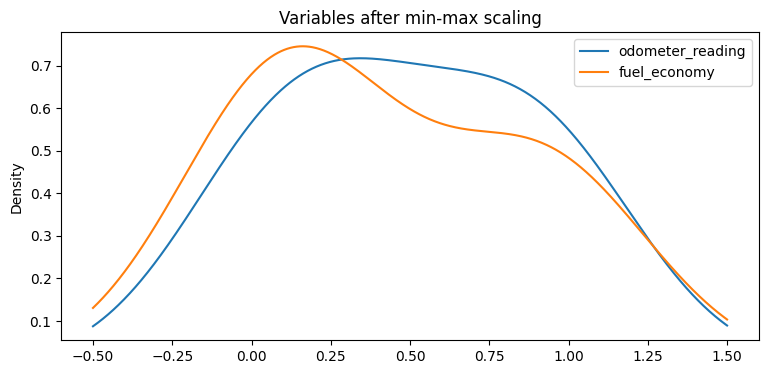

In [50]:
ax = df_cars_normalized.plot(kind='density', figsize=(9, 4))
ax.set_title('Variables after min-max scaling')
plt.show()

**Interpretation:** After scaling, both density curves fit a common horizontal range, making their shapes easier to compare.

#### Method 2:  Using MinMaxScaler

In [51]:
print('Columns to scale:', df_cars.columns.tolist())

Columns to scale: ['odometer_reading', 'fuel_economy']


**Interpretation:** These are the two numeric columns passed to the scaler.

In [52]:
minmax_scaler = MinMaxScaler(feature_range=(0, 1))
df_cars_normalized2 = pd.DataFrame(
    minmax_scaler.fit_transform(df_cars), columns=df_cars.columns, index=df_cars.index,
)
display(df_cars_normalized2)

,odometer_reading,fuel_economy
0,0.000000,0.142857
1,0.464286,0.214286
2,0.196429,0.828571
3,0.821429,1.000000
4,1.000000,0.000000


**Interpretation:** `MinMaxScaler` produces the same 0-to-1 values as the manual formula.

In [53]:
print('Manual and sklearn results match:',
      np.allclose(df_cars_normalized, df_cars_normalized2))
display(df_cars_normalized2)

Manual and sklearn results match: True


,odometer_reading,fuel_economy
0,0.000000,0.142857
1,0.464286,0.214286
2,0.196429,0.828571
3,0.821429,1.000000
4,1.000000,0.000000


**Interpretation:** The equality check confirms the manual and scikit-learn calculations agree to floating-point tolerance.

#####  <font color='purple' > When Should You Use Normalization and Standardization:

Min-max scaling is useful when a bounded feature range is desired, but it is sensitive to extreme values. Standardization centers and rescales each feature and is often helpful when features use different units. Neither method requires a Gaussian distribution. For predictive modeling, fit either scaler on the training set only.

<font color='blue' ><h3>
IV.4.  Dimensionality reduction </p><h3>

The dimensionality of a dataset is the number of input features. Dimensionality reduction replaces those features with a smaller set of summaries. This can help with visualization and, in some settings, model building.

## PCA (Principal component Anlysis):

PCA finds orthogonal directions that explain as much variation as possible. It does not use the outcome label. Below, the notebook works through the covariance matrix and eigenvectors, then checks the result with scikit-learn.

### Method(1): Manual Computation

In [54]:
print('Manual PCA will use NumPy eigen-decomposition of the covariance matrix.')

Manual PCA will use NumPy eigen-decomposition of the covariance matrix.


**Interpretation:** The manual route will expose each PCA calculation before comparing it with scikit-learn.

The required work is to reduce the dimension of the stat2 dataset using PCA in two ways:
1. From scratch using manual computation
2. Computing using "pca" command

Here `stat2` is the horse-colic table. PCA uses five continuous measurements; coded categories and the outcome are excluded. Missing values are replaced by each measurement's median, then the five columns are standardized.

## DataSet: stat2

In [55]:
# Use five continuous measurements, excluding outcome and coded categories.
pca_columns = ['rectal_temp', 'pulse', 'respiratory_rate',
               'packed_cell_volume', 'total_protein']
pca_raw = stat2[pca_columns].apply(pd.to_numeric, errors='coerce')
pca_imputed = pca_raw.fillna(pca_raw.median())
print('Missing values before / after:', int(pca_raw.isna().sum().sum()),
      '/', int(pca_imputed.isna().sum().sum()))
display(pca_imputed.head())

Missing values before / after: 204 / 0


,rectal_temp,pulse,respiratory_rate,packed_cell_volume,total_protein
0,38.5,66.0,28.0,45.0,8.4
1,39.2,88.0,20.0,50.0,85.0
2,38.3,40.0,24.0,33.0,6.7
3,39.1,164.0,84.0,48.0,7.2
4,37.3,104.0,35.0,74.0,7.4


**Interpretation:** Median imputation removes missing cells from five continuous measurements before PCA.

### Step(1): Data centering and reduction

Subtract each feature's mean and divide by its standard deviation. This puts measurements with different units on a comparable scale before calculating principal components.

In [56]:
# Standardize so variables measured in different units contribute comparably.
pca_scaler = StandardScaler()
Z = pca_scaler.fit_transform(pca_imputed)
display(pd.DataFrame(Z, columns=pca_imputed.columns).head())

,rectal_temp,pulse,respiratory_rate,packed_cell_volume,total_protein
0,0.496498,-0.194771,-0.087726,-0.119170,-0.533355
1,1.565603,0.604982,-0.588538,0.385530,2.380057
2,0.191039,-1.139933,-0.338132,-1.330449,-0.598013
3,1.412873,3.367763,3.417962,0.183650,-0.578996
4,-1.336253,1.186620,0.350485,2.808088,-0.571389


**Interpretation:** Standardized measurements have comparable scales, so large units cannot dominate solely by magnitude.

### Step(2): COMPUTATION OF THE COVARANCE MATRIX

In [57]:
covariance = np.cov(Z, rowvar=False)
display(pd.DataFrame(covariance, index=pca_imputed.columns,
                     columns=pca_imputed.columns).round(3))

,rectal_temp,pulse,respiratory_rate,packed_cell_volume,total_protein
rectal_temp,1.003,0.197,0.231,0.058,-0.050
pulse,0.197,1.003,0.435,0.371,-0.083
respiratory_rate,0.231,0.435,1.003,0.067,-0.087
packed_cell_volume,0.058,0.371,0.067,1.003,-0.053
total_protein,-0.050,-0.083,-0.087,-0.053,1.003


**Interpretation:** The diagonal shows standardized variances; off-diagonal entries show how measurements vary together.

#### Step(3): Compute the eigenvectors and eigenvalues of the covariance matrix to identify the principle components.

In [58]:
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
order = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
manual_variance = eigenvalues / eigenvalues.sum()
display(pd.DataFrame({'eigenvalue': eigenvalues,
                      'variance_ratio': manual_variance},
                     index=[f'PC{i}' for i in range(1, len(eigenvalues) + 1)]).round(4))

,eigenvalue,variance_ratio
PC1,1.7537,0.3496
PC2,1.0157,0.2025
PC3,0.9767,0.1947
PC4,0.8071,0.1609
PC5,0.4636,0.0924


**Interpretation:** Components are ordered by decreasing eigenvalue; variance ratios sum to one across all five components.

### Step(4): Projection of the initial data on the new axes (the principal components)

In [59]:
manual_projection = Z @ eigenvectors[:, :2]
display(pd.DataFrame(manual_projection, columns=['PC1', 'PC2']).head())

,PC1,PC2
0,-0.066600,-0.446325
1,-0.360752,0.149367
2,1.238226,-1.274286
3,-4.618527,-1.237492
4,-1.651364,2.779938


**Interpretation:** The two coordinates are each horse's projection onto the first two principal axes.

## Method 2: Computation using "PCA"

In [60]:
print('Using sklearn PCA on the same standardized matrix Z.')

Using sklearn PCA on the same standardized matrix Z.


**Interpretation:** The library calculation below uses exactly the standardized matrix from the manual route.

In [61]:
pca = PCA(n_components=2)
sklearn_projection = pca.fit_transform(Z)
print('Two-component projection:', sklearn_projection.shape)

Two-component projection: (299, 2)


**Interpretation:** The projection has one row per horse and two principal-component coordinates.

In [62]:
display(pd.DataFrame(pca.components_, columns=pca_imputed.columns,
                     index=['PC1', 'PC2']).round(3))
print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 4))

,rectal_temp,pulse,respiratory_rate,packed_cell_volume,total_protein
PC1,0.371,0.623,0.532,0.398,-0.184
PC2,-0.535,0.194,-0.344,0.730,0.162


Explained variance ratio: [0.3496 0.2025]


**Interpretation:** Loadings describe each component's direction; explained-variance ratios show how much variation each retains.

In [63]:
display(pd.DataFrame(sklearn_projection, columns=['PC1', 'PC2']).head())
print('Manual and sklearn absolute score magnitudes agree:',
      np.allclose(np.abs(manual_projection), np.abs(sklearn_projection)))

,PC1,PC2
0,0.066600,-0.446325
1,0.360752,0.149367
2,-1.238226,-1.274286
3,4.618527,-1.237492
4,1.651364,2.779938


Manual and sklearn absolute score magnitudes agree: True


**Interpretation:** Eigenvector signs can flip without changing PCA, so the comparison uses absolute score magnitudes.

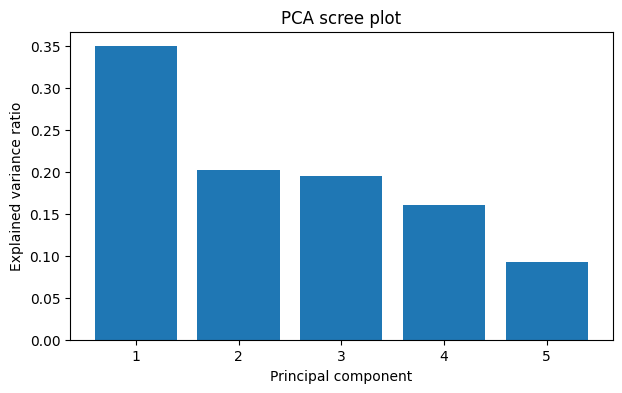

In [64]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(manual_variance) + 1), manual_variance)
ax.set(xlabel='Principal component', ylabel='Explained variance ratio',
       title='PCA scree plot', xticks=range(1, len(manual_variance) + 1))
plt.show()

**Interpretation:** The bars show the share of total standardized variance explained by each component.

In [65]:
# Repeat with all components to show the complete PCA summary.
pca_full = PCA().fit(Z)
display(pd.DataFrame({'explained_variance_ratio': pca_full.explained_variance_ratio_,
                      'cumulative_ratio': np.cumsum(pca_full.explained_variance_ratio_)},
                     index=[f'PC{i}' for i in range(1, Z.shape[1] + 1)]).round(4))
print('All-component projection shape:', pca_full.transform(Z).shape)

,explained_variance_ratio,cumulative_ratio
PC1,0.3496,0.3496
PC2,0.2025,0.5520
PC3,0.1947,0.7467
PC4,0.1609,0.9076
PC5,0.0924,1.0000


All-component projection shape: (299, 5)


**Interpretation:** Cumulative variance shows how many components are needed to retain a chosen share of variation.